# Projeto - Engine de Xadrez
### Daniel Couto

Este projeto pretende desenvolver, testar e comparar diferentes arquiteturas e heurísticas para uma rede neural jogar xadrez. Usarei o dataset https://www.kaggle.com/datasets/ronakbadhe/chess-evaluations?resource=download  

**Objetivos.**
- construir uma engine que avalie e sugira o melhor lance;
- comparar arquiteturas simples e profundas;
- investigar o efeito de escolhas de treinamento;
- analisar erros e limitações do modelo.


### Configurações inicias

In [2]:
import chess
import random
import numpy as np
from pathlib import Path
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import torch.optim as optim
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm


seed = 1981
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Semente: {seed}")
print(f"Dispositivo: {device}")
print("Versão do Torch:", torch.__version__)
print("Versão do Torchvision:", torchvision.__version__)

student_run_tag = "DCP"
output_dir = Path("assignment1_outputs")
output_dir.mkdir(exist_ok=True)
(output_dir / student_run_tag).mkdir(exist_ok=True)
print("Diretório de saída:", output_dir / student_run_tag)

Semente: 1981
Dispositivo: cpu
Versão do Torch: 2.11.0+cu128
Versão do Torchvision: 0.26.0+cu128
Diretório de saída: assignment1_outputs/DCP


/home/daniel-couto/IMPA_Tech/2026.1/ML2/git_curso/ml2_trabalhos_2026/env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Modelo de Avaliação - Engine

Aqui vou construir um modelo capaz de avaliar uma posição de xadrez, e userei uma Tree para a escolha de melhor lance. Treinarei o modelo em um dataset com posições de xadrez e a correspondente avaliação em centipawns pelo StockFish.

### 1. Importação da Dataset e Análise Exploratória

In [5]:
df = pd.read_csv('chessData.csv')
print(df.head())
print(f"Tamanho do dataset: {len(df):.2f}")

                                                 FEN Evaluation
0  rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR ...        -10
1  rnbqkbnr/pppp1ppp/4p3/8/4P3/8/PPPP1PPP/RNBQKBN...        +56
2  rnbqkbnr/pppp1ppp/4p3/8/3PP3/8/PPP2PPP/RNBQKBN...         -9
3  rnbqkbnr/ppp2ppp/4p3/3p4/3PP3/8/PPP2PPP/RNBQKB...        +52
4  rnbqkbnr/ppp2ppp/4p3/3p4/3PP3/8/PPPN1PPP/R1BQK...        -26
Tamanho do dataset: 12958035.00


#### 1.1 Coluna 'Evaluation'

Para tirar informação da coluna de avaliação, como média e desvio padrão, primeiro precisamos transformá-la em float e também tirar as avaliações que "anuciam mate" no formato '#3' , por exemplo, pois ficaria intratável na análise. 

In [6]:
df['Evaluation_clean'] = df['Evaluation'].str.replace('+', '', regex=False)

df = df[~df['Evaluation_clean'].str.contains('#')]

df['Evaluation_clean'] = df['Evaluation_clean'].astype(float)

media_eval = df['Evaluation_clean'].mean()
std_eval = df['Evaluation_clean'].std()

print(f"Estatísticas da Avaliação (Centipawns)")
print(f"Média: {media_eval:.2f}")
print(f"Desvio Padrão: {std_eval:.2f}")
print(f"Total de posições sem mate próximo analisadas: {len(df['Evaluation_clean'])}")

Estatísticas da Avaliação (Centipawns)
Média: 45.51
Desvio Padrão: 813.89
Total de posições sem mate próximo analisadas: 12767881


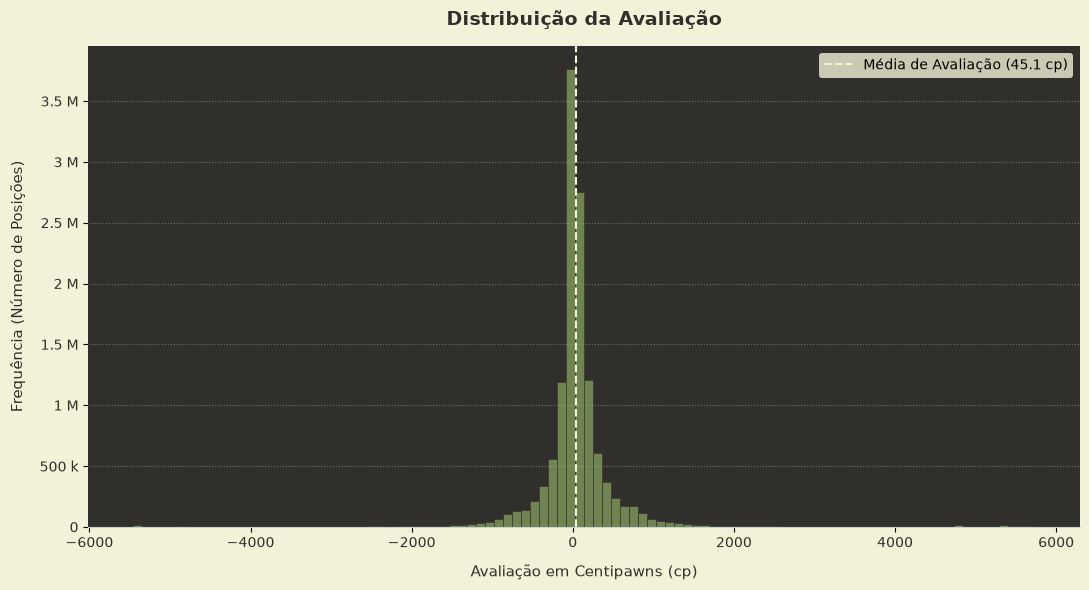

In [7]:
q_low = df['Evaluation_clean'].quantile(0.005)
q_high = df['Evaluation_clean'].quantile(0.995)
df_filtrado = df[(df['Evaluation_clean'] >= q_low) & (df['Evaluation_clean'] <= q_high)]

fig, ax = plt.subplots(figsize=(11, 6))
                                
COR_FUNDO_EXTERNO = '#F1F2D8' 
COR_FUNDO_INTERNO = '#312F2B' 

fig.patch.set_facecolor(COR_FUNDO_EXTERNO) 
ax.set_facecolor(COR_FUNDO_INTERNO)        

n, bins, patches = ax.hist(
    df_filtrado['Evaluation_clean'], 
    bins=100, 
    edgecolor=COR_FUNDO_INTERNO, 
    linewidth=0.5,
    alpha=0.85, 
    color='#7B9459'
)

media_eval = df_filtrado['Evaluation_clean'].mean()

ax.axvline(
    media_eval, 
    color='#F1F2D8', 
    linestyle='--', 
    linewidth=1.5, 
    label=f'Média de Avaliação ({media_eval:.1f} cp)' 
)

ax.set_title('Distribuição da Avaliação', fontsize=14, fontweight='bold', pad=15, color=COR_FUNDO_INTERNO)
ax.set_xlabel('Avaliação em Centipawns (cp)', fontsize=11, labelpad=10, color=COR_FUNDO_INTERNO)
ax.set_ylabel('Frequência (Número de Posições)', fontsize=11, labelpad=10, color=COR_FUNDO_INTERNO)

ax.xaxis.set_tick_params(labelsize=10, labelcolor=COR_FUNDO_INTERNO)
ax.yaxis.set_major_formatter(ticker.EngFormatter())
ax.yaxis.set_tick_params(labelsize=10, labelcolor=COR_FUNDO_INTERNO)

ax.grid(axis='x', visible=False)
ax.grid(axis='y', linestyle=':', alpha=0.6, color='#95a5a6') 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#ccd1d1') 

ax.legend(frameon=True, facecolor='#F1F2D8', edgecolor='none', fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()

Para melhorar a visualização, filtrei para eliminar os 0,5% menores avaliações e as 0,55 maiores avaliações.

#### 1.2 Coluna 'FEN'

Para analisarmos a coluna 'FEN' com as posições, podemos começar explorando as estatísticas sobre a quantidade de peças. Isso pode ser importante para sabermos se o dataset tem algum viés de posições mais de abertura, meio jogo ou finais.

In [8]:
def contar_pecas(fen):
    board = chess.Board(fen)
    return len(board.piece_map())

df['Quantidade_Pecas'] = df['FEN'].apply(contar_pecas)

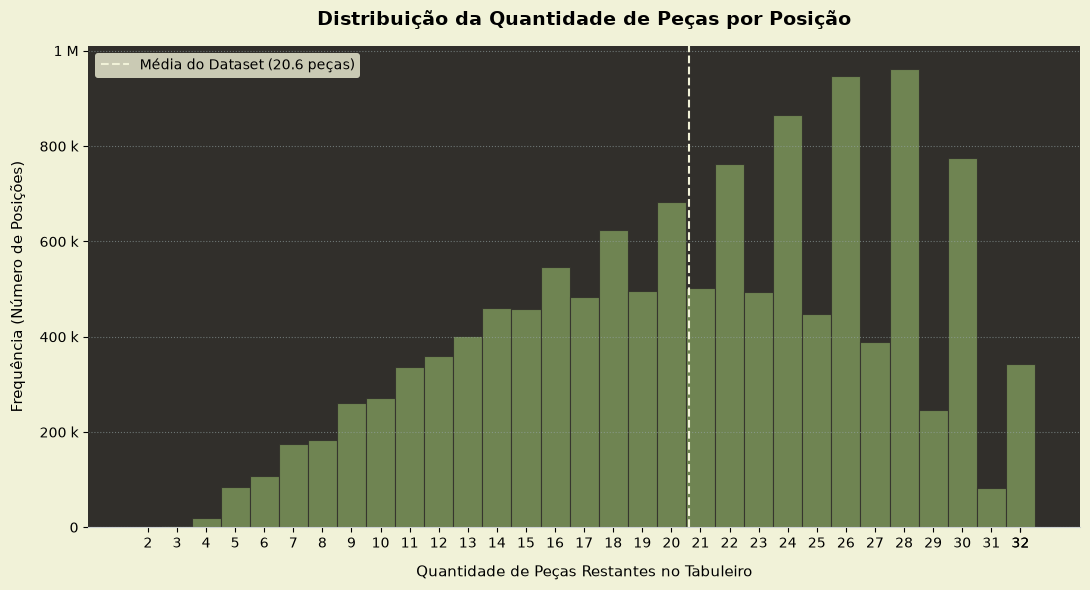

In [9]:
fig, ax = plt.subplots(figsize=(11, 6))

COR_FUNDO_EXTERNO = '#F1F2D8' 
COR_FUNDO_INTERNO = '#312F2B' 

fig.patch.set_facecolor(COR_FUNDO_EXTERNO) 
ax.set_facecolor(COR_FUNDO_INTERNO)        

n, bins, patches = ax.hist(
    df['Quantidade_Pecas'], 
    bins=range(2, 34), 
    edgecolor=COR_FUNDO_INTERNO, 
    linewidth=0.8,
    alpha=0.85, 
    color='#7B9459',           
    align='left'
)

media_pecas = df['Quantidade_Pecas'].mean()

ax.axvline(
    media_pecas, 
    color='#F1F2D8', 
    linestyle='--', 
    linewidth=1.5, 
    label=f'Média do Dataset ({media_pecas:.1f} peças)' 
)

ax.legend(frameon=True, facecolor='#F1F2D8', edgecolor='none', fontsize=10)

ax.set_title('Distribuição da Quantidade de Peças por Posição', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Quantidade de Peças Restantes no Tabuleiro', fontsize=11, labelpad=10)
ax.set_ylabel('Frequência (Número de Posições)', fontsize=11, labelpad=10)

ax.set_xticks(list(range(2, 33, 1)) + [32])
ax.xaxis.set_tick_params(labelsize=10)
ax.yaxis.set_major_formatter(ticker.EngFormatter())
ax.yaxis.set_tick_params(labelsize=10)

ax.grid(axis='x', visible=False)
ax.grid(axis='y', linestyle=':', alpha=0.6, color='#95a5a6') 
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#ccd1d1') 

ax.legend(frameon=True, facecolor='#F1F2D8', edgecolor='none', fontsize=10)

plt.tight_layout()
plt.show()

O histograma mostra uma distribuição bem aceitável de quantidade de peças, mas o que salta de informação é a disparidade de posições com quantidade de peças pares, o que faz bastante sentido e até condiz com a realidade de um jogo, no início é comum que os adversários estejam com a mesma quantidade de peças.

#### 1.3 Split 

In [10]:
df_train, df_temp = train_test_split(df, test_size=0.20, random_state=seed)

df_val, df_test = train_test_split(df_temp, test_size=0.50, random_state=seed)

print(f"Quantidade de exemplos em Treino:   {len(df_train)}")
print(f"Quantidade de exemplos em Validação: {len(df_val)}")
print(f"Quantidade de exemplos em Teste:     {len(df_test)}")

Quantidade de exemplos em Treino:   10214304
Quantidade de exemplos em Validação: 1276788
Quantidade de exemplos em Teste:     1276789


### 2. Modelos

#### 2.1 Tensorização

Para que a CNN receba mais informação, vamos transformar nosso FEN em um tensor de 15 canais: os primeiros 12 funcionam como um mapeamento binário (one-hot) da posição das peças ($8 \times 8$), divididos igualmente entre brancas e pretas, enquanto as últimas 3 camadas adicionam o contexto dinâmico do jogo, onde o canal 12 indica a vez de jogar e os canais 13 e 14 representam os direitos de roque das brancas e das pretas, respectivamente. Essa estrutura entrega o tabuleiro mastigado para a rede, permitindo que os filtros convolucionais foquem direto no aprendizado de conceitos estratégicos.

In [11]:
class Dataset_tensor(Dataset):
    def __init__(self, dataframe):
        self.fens = dataframe['FEN'].values
        self.evals = dataframe['Evaluation_clean'].values

    def __len__(self):
        return len(self.fens)

    def FEN_para_tensor(self, fen):
        board = chess.Board(fen)
        
        tensor = np.zeros((15, 8, 8), dtype=np.float32)
        
        piece_to_channel = {
            (chess.PAWN, chess.WHITE): 0,
            (chess.KNIGHT, chess.WHITE): 1,
            (chess.BISHOP, chess.WHITE): 2,
            (chess.ROOK, chess.WHITE): 3,
            (chess.QUEEN, chess.WHITE): 4,
            (chess.KING, chess.WHITE): 5,
            (chess.PAWN, chess.BLACK): 6,
            (chess.KNIGHT, chess.BLACK): 7,
            (chess.BISHOP, chess.BLACK): 8,
            (chess.ROOK, chess.BLACK): 9,
            (chess.QUEEN, chess.BLACK): 10,
            (chess.KING, chess.BLACK): 11
        }
        
        # 1. Preenche os canais de 0 a 11 com a localização das peças
        for square, piece in board.piece_map().items():
            row = 7 - (square // 8)
            col = square % 8
            channel = piece_to_channel[(piece.piece_type, piece.color)]
            tensor[channel, row, col] = 1.0

        # 2. Canal 12: Vez de jogar 
        if board.turn == chess.WHITE:
            tensor[12, :, :] = 1.0

        # 3. Canal 13: Direitos de roque das Brancas
        if board.has_kingside_castling_rights(chess.WHITE) or board.has_queenside_castling_rights(chess.WHITE):
            tensor[13, :, :] = 1.0

        # 4. Canal 14: Direitos de roque das Pretas
        if board.has_kingside_castling_rights(chess.BLACK) or board.has_queenside_castling_rights(chess.BLACK):
            tensor[14, :, :] = 1.0

        return torch.tensor(tensor)

    def __getitem__(self, idx):
        fen = self.fens[idx]
        y = torch.tensor(self.evals[idx], dtype=torch.float32)
        X = self.FEN_para_tensor(fen)
        return X, y

train_dataset = Dataset_tensor(df_train)
val_dataset = Dataset_tensor(df_val)

batch_size = 256 
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"Total de Batches em Treino: {len(train_loader)}")
print(f"Total de Batches em Validação: {len(val_loader)}")

Total de Batches em Treino: 39900
Total de Batches em Validação: 4988


#### 2.2 CNN (baseline)

In [3]:
class ChessEvalCNN(nn.Module):
    """
    Baseline: CNN simples para avaliação de posições de xadrez.

    Entrada: tensor (batch, 15, 8, 8) -- ver Dataset_tensor.FEN_para_tensor
    Saída:   tensor (batch,) com a avaliação estimada em centipawns

    Arquitetura: 3 blocos Conv2d -> BatchNorm -> ReLU (sem pooling, pois o
    tabuleiro já é pequeno -- 8x8 -- e queremos preservar resolução espacial
    até o final), seguidos de Flatten e uma cabeça densa (MLP) com 2 camadas
    lineares até a saída escalar.
    """
    def __init__(self, in_channels=15, conv_channels=(32, 64, 64), hidden_dim=128, dropout=0.2):
        super().__init__()

        c1, c2, c3 = conv_channels

        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels, c1, kernel_size=3, padding=1),
            nn.BatchNorm2d(c1),
            nn.ReLU(inplace=True),

            nn.Conv2d(c1, c2, kernel_size=3, padding=1),
            nn.BatchNorm2d(c2),
            nn.ReLU(inplace=True),

            nn.Conv2d(c2, c3, kernel_size=3, padding=1),
            nn.BatchNorm2d(c3),
            nn.ReLU(inplace=True),
        )

        # Tabuleiro 8x8 é mantido (padding=1, stride=1) -> achatamos c3 * 8 * 8
        flattened_dim = c3 * 8 * 8

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        x = self.conv_block(x)
        x = self.head(x)
        return x.squeeze(-1)  # (batch, 1) -> (batch,)


model = ChessEvalCNN(in_channels=15).to(device)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTotal de parâmetros treináveis: {n_params:,}")


ChessEvalCNN(
  (conv_block): Sequential(
    (0): Conv2d(15, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
  )
  (head): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=128, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
)

Total de parâmetros treináveis: 584,641


#### 2.2.1 Treinamento


In [13]:
num_epochs = 30
learning_rate = 1e-3
weight_decay = 1e-5
patience = 5  # early stopping

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

print(f"Épocas máximas: {num_epochs}")
print(f"Learning rate inicial: {learning_rate}")
print(f"Weight decay: {weight_decay}")
print(f"Paciência (early stopping): {patience}")
print(f"Loss: {criterion}")
print(f"Otimizador: {optimizer.__class__.__name__}")


Épocas máximas: 30
Learning rate inicial: 0.001
Weight decay: 1e-05
Paciência (early stopping): 5
Loss: MSELoss()
Otimizador: Adam


##### 2.2.2 Loop de Treino

Época 01/30 | Treino MSE: 432219.63 | Validação MSE: 400834.64 | LR: 1.0e-03


Época 02/30 | Treino MSE: 381774.66 | Validação MSE: 367753.49 | LR: 1.0e-03


Época 03/30 | Treino MSE: 364427.00 | Validação MSE: 362740.70 | LR: 1.0e-03


Época 04/30 | Treino MSE: 351733.39 | Validação MSE: 347362.30 | LR: 1.0e-03


Época 05/30 | Treino MSE: 341933.16 | Validação MSE: 344468.22 | LR: 1.0e-03


...

Época 26/30 | Treino MSE: 236752.41 | Validação MSE: 292057.60 | LR: 1.0e-03


Época 27/30 | Treino MSE: 234261.71 | Validação MSE: 287250.13 | LR: 1.0e-03


Época 28/30 | Treino MSE: 231713.99 | Validação MSE: 286915.49 | LR: 1.0e-03


Época 29/30 | Treino MSE: 228989.56 | Validação MSE: 286480.25 | LR: 1.0e-03


Época 30/30 | Treino MSE: 226656.86 | Validação MSE: 286246.93 | LR: 1.0e-03

Melhor Validação MSE: 286246.93
Modelo salvo em: assignment1_outputs/DCP/best_model_baseline_cnn.pt


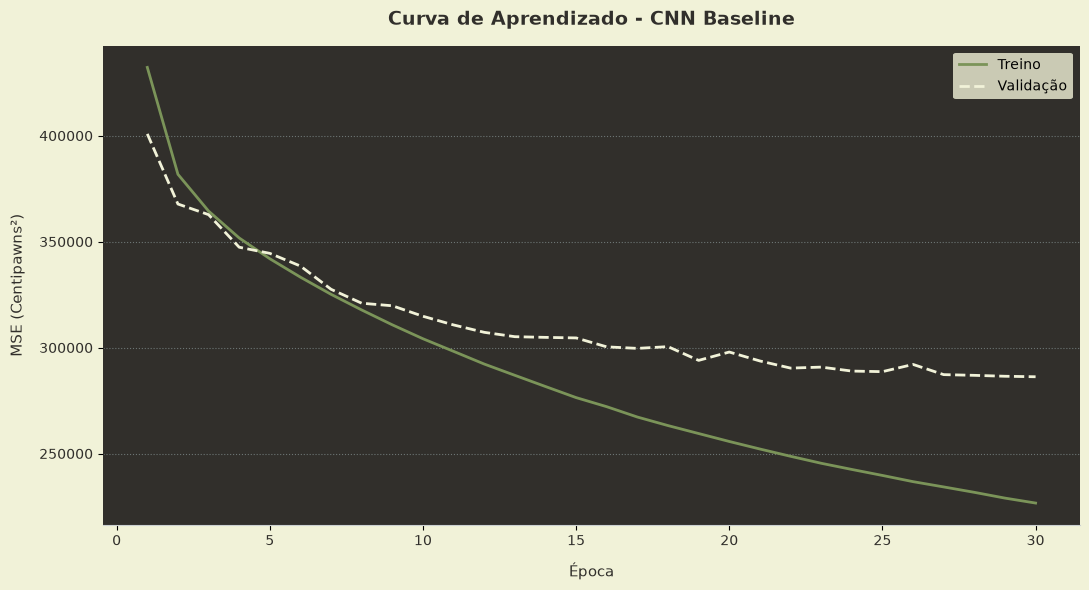

In [13]:
def run_epoch(model, loader, criterion, optimizer=None, device=device):
    """
    Roda uma época de treino (se optimizer for passado) ou de validação
    (se optimizer for None). Retorna a loss média (MSE) na época.
    """
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_samples = 0

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for X, y in tqdm(loader, leave=False, desc="treino" if is_train else "validação"):
            X, y = X.to(device), y.to(device)

            if is_train:
                optimizer.zero_grad()

            preds = model(X)
            loss = criterion(preds, y)

            if is_train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * X.size(0)
            total_samples += X.size(0)

    return total_loss / total_samples


train_losses = []
val_losses = []
best_val_loss = float("inf")
epochs_sem_melhora = 0
best_model_path = output_dir / student_run_tag / "best_model_baseline_cnn.pt"

for epoch in range(1, num_epochs + 1):
    train_loss = run_epoch(model, train_loader, criterion, optimizer, device)
    val_loss = run_epoch(model, val_loader, criterion, optimizer=None, device=device)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Época {epoch:02d}/{num_epochs} | "
        f"Treino MSE: {train_loss:.2f} | "
        f"Validação MSE: {val_loss:.2f} | "
        f"LR: {current_lr:.1e}"
    )

    # Early stopping + checkpoint do melhor modelo
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_sem_melhora = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        epochs_sem_melhora += 1
        if epochs_sem_melhora >= patience:
            print(f"\nEarly stopping na época {epoch} (sem melhora por {patience} épocas).")
            break

print(f"\nMelhor Validação MSE: {best_val_loss:.2f}")
print(f"Modelo salvo em: {best_model_path}")

# Carrega o melhor checkpoint antes de seguir para análises/teste
model.load_state_dict(torch.load(best_model_path, map_location=device))

# Curva de treino x validação
fig, ax = plt.subplots(figsize=(11, 6))

COR_FUNDO_EXTERNO = '#F1F2D8'
COR_FUNDO_INTERNO = '#312F2B'

fig.patch.set_facecolor(COR_FUNDO_EXTERNO)
ax.set_facecolor(COR_FUNDO_INTERNO)

ax.plot(range(1, len(train_losses) + 1), train_losses, color='#7B9459', linewidth=2, label='Treino')
ax.plot(range(1, len(val_losses) + 1), val_losses, color='#F1F2D8', linewidth=2, linestyle='--', label='Validação')

ax.set_title('Curva de Aprendizado - CNN Baseline', fontsize=14, fontweight='bold', pad=15, color=COR_FUNDO_INTERNO)
ax.set_xlabel('Época', fontsize=11, labelpad=10, color=COR_FUNDO_INTERNO)
ax.set_ylabel('MSE (Centipawns²)', fontsize=11, labelpad=10, color=COR_FUNDO_INTERNO)

ax.xaxis.set_tick_params(labelsize=10, labelcolor=COR_FUNDO_INTERNO)
ax.yaxis.set_tick_params(labelsize=10, labelcolor=COR_FUNDO_INTERNO)

ax.grid(axis='x', visible=False)
ax.grid(axis='y', linestyle=':', alpha=0.6, color='#95a5a6')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#ccd1d1')

ax.legend(frameon=True, facecolor='#F1F2D8', edgecolor='none', fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()


### 2.3 ResNet

Para a segunda arquitetura, vou implementar uma **ResNet** (Residual Network) adaptada ao tamanho do nosso "tabuleiro-imagem" ($8 \times 8$). A motivação é simples: a CNN baseline empilha convoluções diretamente, e ao aprofundarmos essa pilha (mais camadas, mais capacidade de capturar padrões táticos como combinações de peças, ataques duplos, etc.) corremos o risco de degradação do gradiente e dificuldade de otimização. As conexões residuais (`skip connections`) resolvem isso permitindo que o gradiente "pule" blocos, facilitando o treinamento de redes mais profundas sem perda de desempenho.

**Arquitetura.**
- Um *stem* inicial (`Conv2d` 3x3 + `BatchNorm` + `ReLU`) que projeta os 15 canais de entrada para a dimensão interna do modelo;
- Uma sequência de **blocos residuais** (`ResidualBlock`), cada um com duas convoluções 3x3 + BatchNorm, ligadas por uma soma residual ($x + F(x)$) seguida de ReLU;
- Mantemos `stride=1` e `padding=1` em todas as convoluções (sem nenhum *pooling* ou *downsampling*), já que o tabuleiro 8x8 já é pequeno e queremos preservar a resolução espacial completa: cada posição da matriz $8\times 8$ continua representando uma casa do tabuleiro até o fim da parte convolucional;
- Ao final, um `AdaptiveAvgPool2d(1)` ("global average pooling") condensa o mapa espacial em um vetor por canal, uma escolha mais robusta que o `Flatten` usado no baseline, pois reduz drasticamente o número de parâmetros da cabeça densa e ajuda a evitar overfitting com uma rede mais profunda;
- Uma cabeça densa (MLP) idêntica em espírito à do baseline, com `Dropout` para regularização, terminando em uma saída escalar (avaliação em centipawns).

In [15]:
class ResidualBlock(nn.Module):
    """
    Bloco residual básico (pré-ativação ao estilo ResNet v1, adaptado):
    duas convoluções 3x3 (stride=1, padding=1 -> preserva 8x8) com
    BatchNorm, somadas ao input original (skip connection) e seguidas
    de ReLU. Quando in_channels != out_channels, uma projeção 1x1
    (shortcut) ajusta a dimensão do atalho.
    """
    def __init__(self, in_channels, out_channels, dropout=0.0):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout2d(dropout) if dropout > 0 else nn.Identity()

        # Shortcut: projeção 1x1 apenas quando o número de canais muda
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.dropout(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + identity  # skip connection
        out = self.relu(out)
        return out


class ChessEvalResNet(nn.Module):
    """
    ResNet para avaliação de posições de xadrez.

    Entrada: tensor (batch, 15, 8, 8) -- ver Dataset_tensor.FEN_para_tensor
    Saída:   tensor (batch,) com a avaliação estimada em centipawns

    Arquitetura: stem (Conv-BN-ReLU) seguido de uma pilha de blocos
    residuais (sem pooling, já que o tabuleiro 8x8 já é pequeno e
    queremos preservar resolução espacial), Global Average Pooling e
    uma cabeça densa (MLP) até a saída escalar.
    """
    def __init__(self, in_channels=15, stem_channels=64, block_channels=(64, 128, 128, 256),
                 hidden_dim=256, dropout=0.3):
        super().__init__()

        # Stem: projeta os 15 canais de entrada para a dimensão interna do modelo
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, stem_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(stem_channels),
            nn.ReLU(inplace=True),
        )

        # Pilha de blocos residuais -- mantém 8x8 em todo o caminho
        blocks = []
        prev_channels = stem_channels
        for out_channels in block_channels:
            blocks.append(ResidualBlock(prev_channels, out_channels, dropout=dropout * 0.5))
            prev_channels = out_channels
        self.res_blocks = nn.Sequential(*blocks)

        # Global Average Pooling: condensa (C, 8, 8) -> (C, 1, 1)
        self.gap = nn.AdaptiveAvgPool2d(1)

        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(prev_channels, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.res_blocks(x)
        x = self.gap(x)
        x = self.head(x)
        return x.squeeze(-1)  # (batch, 1) -> (batch,)


resnet_model = ChessEvalResNet(in_channels=15).to(device)

n_params_resnet = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)
print(resnet_model)
print(f"\nTotal de parâmetros treináveis: {n_params_resnet:,}")
print(f"(Baseline CNN tinha {n_params:,} parâmetros)")


ChessEvalResNet(
  (stem): Sequential(
    (0): Conv2d(15, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (res_blocks): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (dropout): Dropout2d(p=0.15, inplace=False)
      (shortcut): Identity()
    )
    (1): ResidualBlock(
      (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

#### 2.3.1 Treinamento

Vou usar essencialmente o mesmo esquema de treinamento da CNN baseline (mesma loss MSE, mesmo otimizador Adam, mesmo scheduler `ReduceLROnPlateau` e mesma estratégia de early stopping), reaproveitando a função `run_epoch` já definida, para que a comparação entre as duas arquiteturas seja justa. A única diferença é o `learning_rate` inicial um pouco menor, já que a ResNet é mais profunda e mais sensível a passos grandes no início do treino.

In [16]:
num_epochs_resnet = 30
learning_rate_resnet = 5e-4
weight_decay_resnet = 1e-5
patience_resnet = 5  # early stopping

criterion_resnet = nn.MSELoss()
optimizer_resnet = optim.Adam(resnet_model.parameters(), lr=learning_rate_resnet, weight_decay=weight_decay_resnet)
scheduler_resnet = optim.lr_scheduler.ReduceLROnPlateau(optimizer_resnet, mode='min', factor=0.5, patience=2)

print(f"Épocas máximas: {num_epochs_resnet}")
print(f"Learning rate inicial: {learning_rate_resnet}")
print(f"Weight decay: {weight_decay_resnet}")
print(f"Paciência (early stopping): {patience_resnet}")
print(f"Loss: {criterion_resnet}")
print(f"Otimizador: {optimizer_resnet.__class__.__name__}")


Épocas máximas: 30
Learning rate inicial: 0.0005
Weight decay: 1e-05
Paciência (early stopping): 5
Loss: MSELoss()
Otimizador: Adam


##### 2.3.2 Loop de Treino

Época 01/30 | Treino MSE: 447844.38 | Validação MSE: 393011.59 | LR: 5.0e-04


Época 02/30 | Treino MSE: 386703.93 | Validação MSE: 362118.75 | LR: 5.0e-04


Época 03/30 | Treino MSE: 364014.71 | Validação MSE: 349980.11 | LR: 5.0e-04


Época 04/30 | Treino MSE: 348684.74 | Validação MSE: 337497.31 | LR: 5.0e-04


Época 05/30 | Treino MSE: 336391.39 | Validação MSE: 328577.99 | LR: 5.0e-04


...

Época 26/30 | Treino MSE: 193415.29 | Validação MSE: 258388.32 | LR: 2.5e-04


Época 27/30 | Treino MSE: 190694.31 | Validação MSE: 255296.47 | LR: 2.5e-04


Época 28/30 | Treino MSE: 188296.35 | Validação MSE: 258993.15 | LR: 2.5e-04


Época 29/30 | Treino MSE: 186216.22 | Validação MSE: 256318.61 | LR: 2.5e-04


Época 30/30 | Treino MSE: 184000.46 | Validação MSE: 255498.89 | LR: 1.3e-04

Melhor Validação MSE: 255296.47
Modelo salvo em: assignment1_outputs/DCP/best_model_resnet.pt


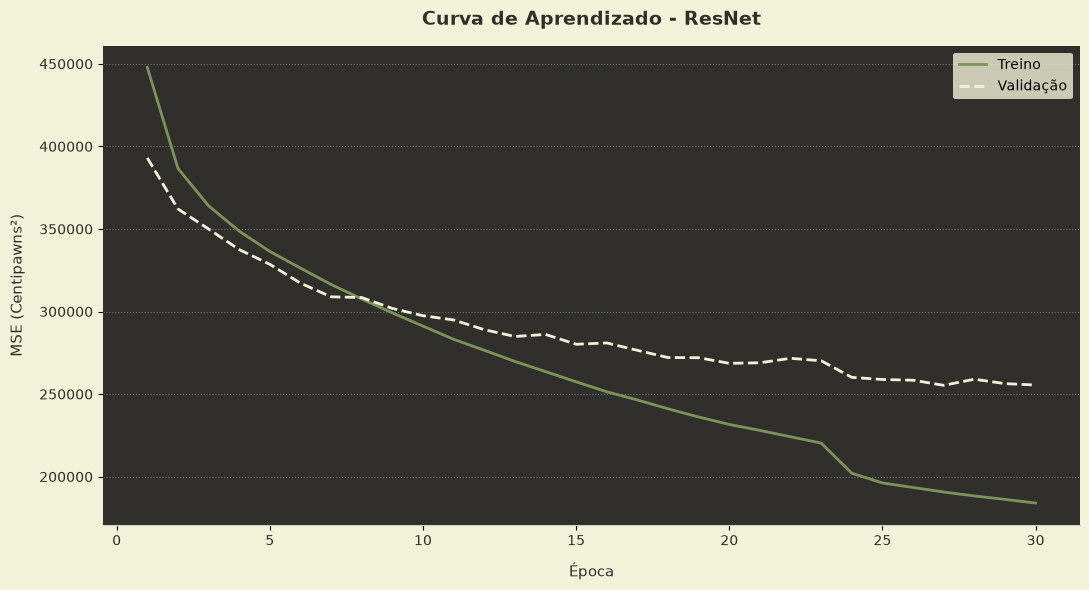

In [17]:
train_losses_resnet = []
val_losses_resnet = []
best_val_loss_resnet = float("inf")
epochs_sem_melhora_resnet = 0
best_model_path_resnet = output_dir / student_run_tag / "best_model_resnet.pt"

for epoch in range(1, num_epochs_resnet + 1):
    train_loss = run_epoch(resnet_model, train_loader, criterion_resnet, optimizer_resnet, device)
    val_loss = run_epoch(resnet_model, val_loader, criterion_resnet, optimizer=None, device=device)

    scheduler_resnet.step(val_loss)
    current_lr = optimizer_resnet.param_groups[0]["lr"]

    train_losses_resnet.append(train_loss)
    val_losses_resnet.append(val_loss)

    print(
        f"Época {epoch:02d}/{num_epochs_resnet} | "
        f"Treino MSE: {train_loss:.2f} | "
        f"Validação MSE: {val_loss:.2f} | "
        f"LR: {current_lr:.1e}"
    )

    # Early stopping + checkpoint do melhor modelo
    if val_loss < best_val_loss_resnet:
        best_val_loss_resnet = val_loss
        epochs_sem_melhora_resnet = 0
        torch.save(resnet_model.state_dict(), best_model_path_resnet)
    else:
        epochs_sem_melhora_resnet += 1
        if epochs_sem_melhora_resnet >= patience_resnet:
            print(f"\nEarly stopping na época {epoch} (sem melhora por {patience_resnet} épocas).")
            break

print(f"\nMelhor Validação MSE: {best_val_loss_resnet:.2f}")
print(f"Modelo salvo em: {best_model_path_resnet}")

# Carrega o melhor checkpoint antes de seguir para análises/teste
resnet_model.load_state_dict(torch.load(best_model_path_resnet, map_location=device))

# Curva de treino x validação
fig, ax = plt.subplots(figsize=(11, 6))

COR_FUNDO_EXTERNO = '#F1F2D8'
COR_FUNDO_INTERNO = '#312F2B'

fig.patch.set_facecolor(COR_FUNDO_EXTERNO)
ax.set_facecolor(COR_FUNDO_INTERNO)

ax.plot(range(1, len(train_losses_resnet) + 1), train_losses_resnet, color='#7B9459', linewidth=2, label='Treino')
ax.plot(range(1, len(val_losses_resnet) + 1), val_losses_resnet, color='#F1F2D8', linewidth=2, linestyle='--', label='Validação')

ax.set_title('Curva de Aprendizado - ResNet', fontsize=14, fontweight='bold', pad=15, color=COR_FUNDO_INTERNO)
ax.set_xlabel('Época', fontsize=11, labelpad=10, color=COR_FUNDO_INTERNO)
ax.set_ylabel('MSE (Centipawns²)', fontsize=11, labelpad=10, color=COR_FUNDO_INTERNO)

ax.xaxis.set_tick_params(labelsize=10, labelcolor=COR_FUNDO_INTERNO)
ax.yaxis.set_tick_params(labelsize=10, labelcolor=COR_FUNDO_INTERNO)

ax.grid(axis='x', visible=False)
ax.grid(axis='y', linestyle=':', alpha=0.6, color='#95a5a6')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#ccd1d1')

ax.legend(frameon=True, facecolor='#F1F2D8', edgecolor='none', fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()


### 2.4 Avaliação em conjunto de teste independente, por fase do jogo

Até aqui, `val_losses`/`val_losses_resnet` medem o erro (MSE) em um split do **mesmo dataset** (`chessData.csv`) usado no treino. Para uma checagem mais honesta, uso `random_evals.csv`, um segundo dataset (mesma pasta), com posições e avaliações do Stockfish de origem diferente (posições geradas por lances aleatórios, não extraídas de partidas reais), como teste fora da distribuição de treino, agora medindo **MAE** (erro absoluto médio, em centipawns, mais interpretável que o MSE) e quebrando por fase do jogo.

A pergunta principal: **o erro dos modelos é uniforme ao longo do jogo, ou eles são bons em algumas fases e ruins em outras?** Uso a quantidade de peças no tabuleiro como proxy da fase (a mesma lógica de `contar_pecas` da seção 1.2):
- **Abertura**: 24-32 peças
- **Meio-jogo**: 12-23 peças
- **Final**: menos de 12 peças

Como o arquivo tem ~1 milhão de posições e rodar os dois modelos em todas seria lento sem necessidade estatística, uso uma amostra aleatória de 20.000 posições (mesma seed do resto do notebook, para reprodutibilidade).

In [23]:
df_random = pd.read_csv('random_evals.csv')

df_random['Evaluation_clean'] = df_random['Evaluation'].str.replace('+', '', regex=False)
df_random = df_random[~df_random['Evaluation_clean'].str.contains('#')]
df_random['Evaluation_clean'] = df_random['Evaluation_clean'].astype(float)

amostra_random = df_random.sample(n=20000, random_state=seed).reset_index(drop=True)
amostra_random['Quantidade_Pecas'] = amostra_random['FEN'].apply(contar_pecas)

print(f"Total no arquivo: {len(df_random):,}")
print(f"Amostra de teste: {len(amostra_random):,} posições")
amostra_random.head()

Total no arquivo: 944,009
Amostra de teste: 20,000 posições


,FEN,Evaluation,Evaluation_clean,Quantidade_Pecas
0,rnbqkbnr/p1p2ppp/1p6/3pp3/P2P3P/8/1PP1PPP1/RNBQKBNR w KQkq - 0 4,+144,144.0,32
1,rqb1k2r/pp1pnpbp/3Q2p1/4p3/1PB1P3/P3B3/4NPPP/2R2RK1 b kq - 4 15,-1136,-1136.0,27
2,rnbqk1nr/pppp1ppp/8/2b1p3/8/6P1/PPPPPP1P/RNBQKBNR b KQkq - 3 3,-140,-140.0,32
3,3q1rk1/R4ppp/5p2/3p4/2pP2P1/2bNPP2/5r1P/Q4RK1 w - - 1 26,-35,-35.0,21
4,4q1nk/3bb1pp/p3p3/1p2P3/1P1Pp1PP/P3B3/4Q3/2RN2K1 b - - 1 34,+207,207.0,22


In [24]:
def prever_em_lote(modelo, fens, batch_size=512):
    """Roda o modelo em lotes sobre uma lista de FENs e devolve as previsões (numpy)."""
    modelo.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(fens), batch_size):
            lote = fens[i:i + batch_size]
            X = torch.stack([train_dataset.FEN_para_tensor(f) for f in lote]).to(device)
            preds.append(modelo(X).cpu().numpy())
    return np.concatenate(preds)


pred_cnn = prever_em_lote(model, amostra_random['FEN'].tolist())
pred_resnet = prever_em_lote(resnet_model, amostra_random['FEN'].tolist())

amostra_random['erro_abs_cnn'] = np.abs(pred_cnn - amostra_random['Evaluation_clean'].values)
amostra_random['erro_abs_resnet'] = np.abs(pred_resnet - amostra_random['Evaluation_clean'].values)

print(f"MAE CNN Baseline (geral): {amostra_random['erro_abs_cnn'].mean():.2f} cp")
print(f"MAE ResNet (geral):       {amostra_random['erro_abs_resnet'].mean():.2f} cp")

MAE CNN Baseline (geral): 455.96 cp
MAE ResNet (geral):       432.28 cp


In [25]:
def fase_do_jogo(n_pecas):
    if n_pecas >= 24:
        return 'Abertura'
    elif n_pecas >= 12:
        return 'Meio-jogo'
    return 'Final'

amostra_random['fase'] = amostra_random['Quantidade_Pecas'].apply(fase_do_jogo)

print("Contagem de posições por fase:")
print(amostra_random['fase'].value_counts().reindex(['Abertura', 'Meio-jogo', 'Final']))

mae_por_fase = (amostra_random.groupby('fase')[['erro_abs_cnn', 'erro_abs_resnet']]
                 .mean().reindex(['Abertura', 'Meio-jogo', 'Final']))
mae_por_fase.columns = ['MAE CNN Baseline (cp)', 'MAE ResNet (cp)']
mae_por_fase

Contagem de posições por fase:
fase
Abertura     12465
Meio-jogo     6768
Final          767
Name: count, dtype: int64


,MAE CNN Baseline (cp),MAE ResNet (cp)
fase,,
Abertura,333.168161,325.969842
Meio-jogo,569.410359,544.562931
Final,1450.513816,1169.262889


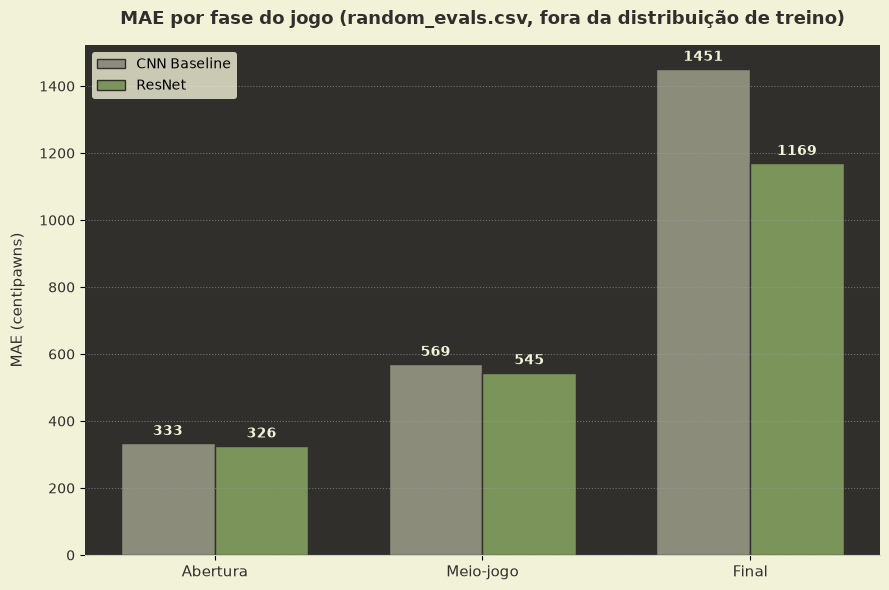

In [26]:
COR_CNN = '#8C8C7A'   # cinza neutro para o baseline
# COR_RESNET ('#7B9459') já foi definida na seção 3 -- mesma identidade em todo o notebook

fases = ['Abertura', 'Meio-jogo', 'Final']
x = np.arange(len(fases))
largura = 0.35

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor(COR_FUNDO_EXTERNO)
ax.set_facecolor(COR_FUNDO_INTERNO)

barras_cnn = ax.bar(x - largura / 2, mae_por_fase['MAE CNN Baseline (cp)'], largura,
                     color=COR_CNN, edgecolor=COR_FUNDO_INTERNO, label='CNN Baseline')
barras_resnet = ax.bar(x + largura / 2, mae_por_fase['MAE ResNet (cp)'], largura,
                        color='#7B9459', edgecolor=COR_FUNDO_INTERNO, label='ResNet')

for barras in (barras_cnn, barras_resnet):
    for bar in barras:
        altura = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, altura + 15, f'{altura:.0f}', ha='center', va='bottom',
                color=COR_FUNDO_EXTERNO, fontsize=10, fontweight='bold')

ax.set_title('MAE por fase do jogo (random_evals.csv, fora da distribuição de treino)',
              fontsize=13, fontweight='bold', pad=15, color=COR_FUNDO_INTERNO)
ax.set_ylabel('MAE (centipawns)', fontsize=11, labelpad=10, color=COR_FUNDO_INTERNO)
ax.set_xticks(x)
ax.set_xticklabels(fases)

ax.xaxis.set_tick_params(labelsize=11, labelcolor=COR_FUNDO_INTERNO)
ax.yaxis.set_tick_params(labelsize=10, labelcolor=COR_FUNDO_INTERNO)
ax.grid(axis='x', visible=False)
ax.grid(axis='y', linestyle=':', alpha=0.6, color='#95a5a6')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#ccd1d1')
ax.legend(frameon=True, facecolor=COR_FUNDO_EXTERNO, edgecolor='none', fontsize=10, loc='upper left')

plt.tight_layout()
plt.show()

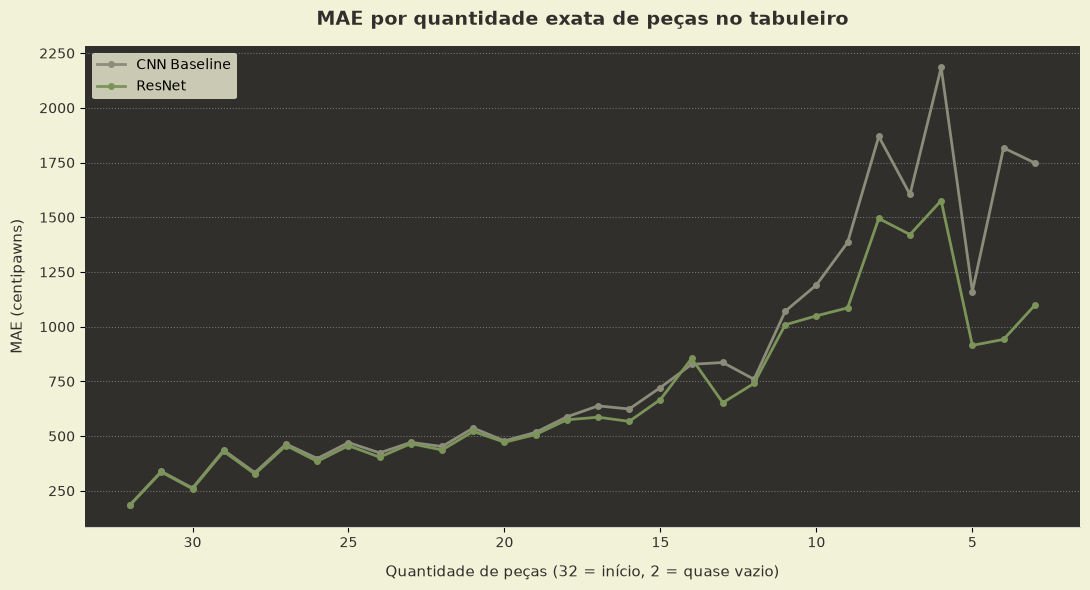

In [27]:
mae_por_pecas = amostra_random.groupby('Quantidade_Pecas')[['erro_abs_cnn', 'erro_abs_resnet']].mean()

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(COR_FUNDO_EXTERNO)
ax.set_facecolor(COR_FUNDO_INTERNO)

ax.plot(mae_por_pecas.index, mae_por_pecas['erro_abs_cnn'], color=COR_CNN, linewidth=2,
        marker='o', markersize=4, label='CNN Baseline')
ax.plot(mae_por_pecas.index, mae_por_pecas['erro_abs_resnet'], color='#7B9459', linewidth=2,
        marker='o', markersize=4, label='ResNet')

ax.set_title('MAE por quantidade exata de peças no tabuleiro', fontsize=14, fontweight='bold', pad=15, color=COR_FUNDO_INTERNO)
ax.set_xlabel('Quantidade de peças (32 = início, 2 = quase vazio)', fontsize=11, labelpad=10, color=COR_FUNDO_INTERNO)
ax.set_ylabel('MAE (centipawns)', fontsize=11, labelpad=10, color=COR_FUNDO_INTERNO)
ax.invert_xaxis()  # abertura (32) à esquerda -> final (poucas peças) à direita, como o jogo "flui"

ax.xaxis.set_tick_params(labelsize=10, labelcolor=COR_FUNDO_INTERNO)
ax.yaxis.set_tick_params(labelsize=10, labelcolor=COR_FUNDO_INTERNO)
ax.grid(axis='x', visible=False)
ax.grid(axis='y', linestyle=':', alpha=0.6, color='#95a5a6')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#ccd1d1')
ax.legend(frameon=True, facecolor=COR_FUNDO_EXTERNO, edgecolor='none', fontsize=10, loc='upper left')

plt.tight_layout()
plt.show()

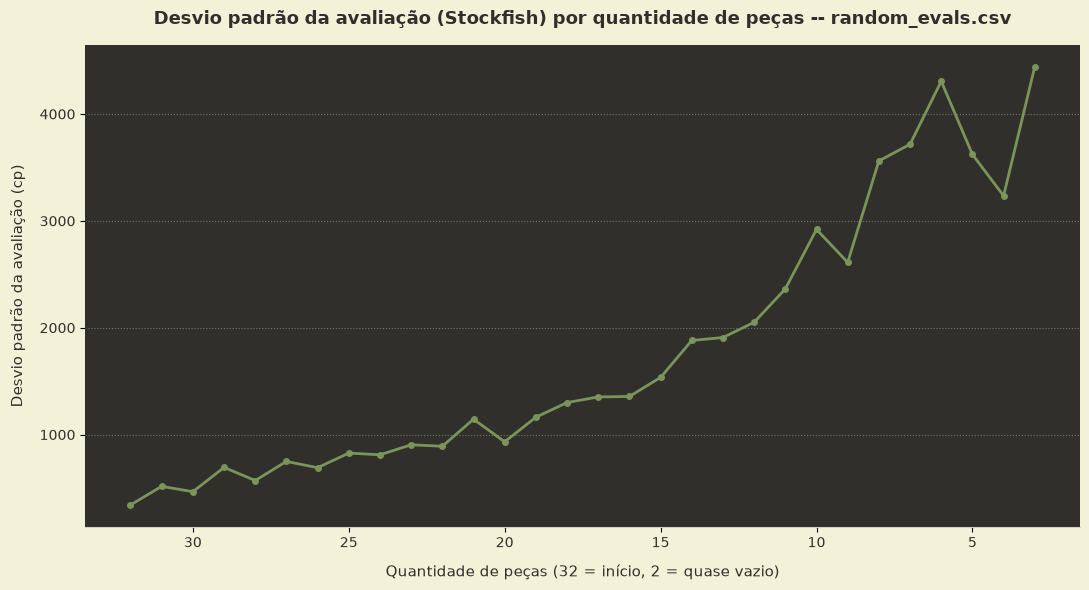

In [25]:
std_por_pecas = amostra_random.groupby('Quantidade_Pecas')['Evaluation_clean'].std()

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(COR_FUNDO_EXTERNO)
ax.set_facecolor(COR_FUNDO_INTERNO)

ax.plot(std_por_pecas.index, std_por_pecas.values, color='#7B9459', linewidth=2,
        marker='o', markersize=4)

ax.set_title('Desvio padrão da avaliação (Stockfish) por quantidade de peças -- random_evals.csv',
              fontsize=13, fontweight='bold', pad=15, color=COR_FUNDO_INTERNO)
ax.set_xlabel('Quantidade de peças (32 = início, 2 = quase vazio)', fontsize=11, labelpad=10, color=COR_FUNDO_INTERNO)
ax.set_ylabel('Desvio padrão da avaliação (cp)', fontsize=11, labelpad=10, color=COR_FUNDO_INTERNO)
ax.invert_xaxis()

ax.xaxis.set_tick_params(labelsize=10, labelcolor=COR_FUNDO_INTERNO)
ax.yaxis.set_tick_params(labelsize=10, labelcolor=COR_FUNDO_INTERNO)
ax.grid(axis='x', visible=False)
ax.grid(axis='y', linestyle=':', alpha=0.6, color='#95a5a6')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#ccd1d1')

plt.tight_layout()
plt.show()

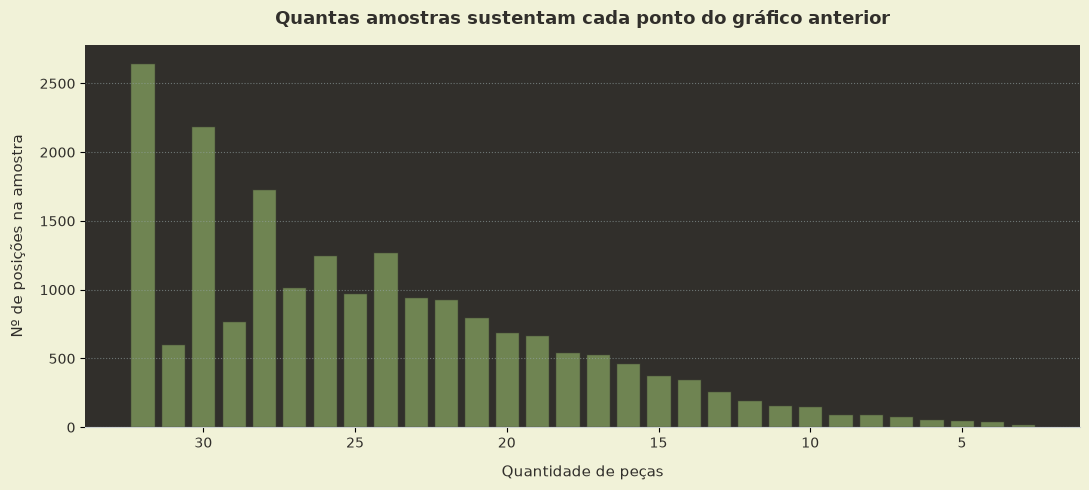

In [28]:
contagem_por_pecas = amostra_random['Quantidade_Pecas'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor(COR_FUNDO_EXTERNO)
ax.set_facecolor(COR_FUNDO_INTERNO)

ax.bar(contagem_por_pecas.index, contagem_por_pecas.values, color='#7B9459',
       edgecolor=COR_FUNDO_INTERNO, alpha=0.85, width=0.8)

ax.set_title('Quantas amostras sustentam cada ponto do gráfico anterior', fontsize=13, fontweight='bold', pad=15, color=COR_FUNDO_INTERNO)
ax.set_xlabel('Quantidade de peças', fontsize=11, labelpad=10, color=COR_FUNDO_INTERNO)
ax.set_ylabel('Nº de posições na amostra', fontsize=11, labelpad=10, color=COR_FUNDO_INTERNO)
ax.invert_xaxis()

ax.xaxis.set_tick_params(labelsize=10, labelcolor=COR_FUNDO_INTERNO)
ax.yaxis.set_tick_params(labelsize=10, labelcolor=COR_FUNDO_INTERNO)
ax.grid(axis='x', visible=False)
ax.grid(axis='y', linestyle=':', alpha=0.6, color='#95a5a6')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#ccd1d1')

plt.tight_layout()
plt.show()

#### 2.4.1 Discussão

**O erro cresce muito conforme o jogo esvazia.** No geral (20.000 posições), a ResNet erra em média **432 cp** contra **456 cp** do CNN Baseline: uma vantagem modesta. Mas essa média esconde uma variação enorme por fase:

| Fase | CNN Baseline | ResNet |
|---|---|---|
| Abertura (≥24 peças) | ~333 cp | ~326 cp |
| Meio-jogo (12-23 peças) | ~569 cp | ~545 cp |
| Final (<12 peças) | ~1451 cp | ~1169 cp |

Na abertura os dois modelos praticamente empatam; no final de jogo o erro de ambos passa de **1000 cp**, mais que o valor de uma dama, e é onde a ResNet mais se destaca da CNN baseline (uma redução de ~280 cp, a maior diferença absoluta entre as duas arquiteturas em qualquer fase).

**Por que o final é tão mais difícil?** Duas causas prováveis, e não são excludentes:
1. **Menos dados de treino** nessa faixa: o gráfico de contagem por peça mostra que posições com poucas peças são bem mais raras na amostra (e, por extensão, no dataset de treino `chessData.csv`, que tem a mesma origem de partidas reais). O modelo simplesmente viu menos exemplos desse regime.
2. **A própria natureza da avaliação muda** perto do final: com poucas peças, a diferença entre "levemente melhor" e "mate forçado em 3" pode ser um único lance: a função de avaliação (regressão em centipawns) precisa capturar não-linearidades muito mais abruptas do que em uma abertura equilibrada, onde a avaliação evolui suavemente.

**Cuidado com os extremos:** o gráfico de contagem também mostra que as faixas de 3 a 10 peças têm poucas dezenas/centenas de amostras (contra milhares na abertura): os pontos mais à direita do gráfico de MAE por peça são, portanto, os menos confiáveis estatisticamente, mesmo sendo os que mostram o maior erro. Isso reforça a leitura por fase (que agrega essas faixas) como mais robusta do que olhar cada contagem de peça isoladamente.

### 3. ResNet vs DQN: Confronto direto (self-play com minimax)

Com as duas arquiteturas de avaliação treinadas, vale a pergunta natural: qual delas joga melhor xadrez de fato? Para responder, coloquei os dois modelos para jogar um contra o outro, cada um plugado como função de avaliação em uma busca **minimax com poda alfa-beta** de profundidade fixa (3 meios-lances), implementada em `search_common.MinimaxSearch` (repositório `lichess-bot`, reaproveitado deste projeto).

**Metodologia.** Como a busca de cada modelo é totalmente determinística (sem nenhuma fonte de aleatoriedade), rodar "10 jogos" a partir da posição inicial padrão produziria só 2 jogos únicos repetidos 5 vezes cada. Para gerar 10 confrontos genuinamente distintos, cada jogo parte de uma abertura diferente (Aberto, Siciliana, Francesa, Caro-Kann, Gambito da Dama, Inglesa, Réti, etc.) e as cores são alternadas: cada modelo joga 5 vezes de brancas e 5 de pretas.

In [18]:
part0 = json.loads(Path('resnet_vs_dqn_part0.json').read_text())
part1 = json.loads(Path('resnet_vs_dqn_part1.json').read_text())
jogos = sorted(part0 + part1, key=lambda g: g['game_idx'])

df_jogos = pd.DataFrame([{
    'jogo': g['game_idx'],
    'brancas': g['white_model'],
    'pretas': g['black_model'],
    'vencedor': g['winner_model'] or 'empate',
    'termino': g['termination'],
    'lances': g['num_plies'],
} for g in jogos])

print(f"Total de jogos: {len(df_jogos)}")
df_jogos

Total de jogos: 10


,jogo,brancas,pretas,vencedor,termino,lances
0,1,resnet,dqn,empate,FIVEFOLD_REPETITION,46
1,2,dqn,resnet,resnet,CHECKMATE,50
2,3,resnet,dqn,resnet,CHECKMATE,23
3,4,dqn,resnet,resnet,CHECKMATE,38
4,5,resnet,dqn,resnet,CHECKMATE,39
5,6,dqn,resnet,resnet,CHECKMATE,22
6,7,resnet,dqn,resnet,CHECKMATE,41
7,8,dqn,resnet,empate,FIVEFOLD_REPETITION,52
8,9,resnet,dqn,resnet,CHECKMATE,23
9,10,dqn,resnet,resnet,CHECKMATE,28


In [19]:
# Tempo por lance de cada modelo (excluindo 1 outlier: a máquina suspendeu/dormiu
# no meio do jogo 10, inflando um único lance para ~32h de tempo de PAREDE --
# não é tempo de cálculo real, então filtramos qualquer lance > 1000s).
resnet_times, dqn_times = [], []
for g in jogos:
    for m in g['moves']:
        if m['seconds'] > 1000:
            continue
        (resnet_times if m['by'] == 'resnet' else dqn_times).append(m['seconds'])

print(f"ResNet: {len(resnet_times)} lances | média {np.mean(resnet_times):.1f}s | mediana {np.median(resnet_times):.1f}s")
print(f"DQN:    {len(dqn_times)} lances | média {np.mean(dqn_times):.1f}s | mediana {np.median(dqn_times):.1f}s")

ResNet: 172 lances | média 37.0s | mediana 30.7s
DQN:    167 lances | média 15.2s | mediana 12.3s


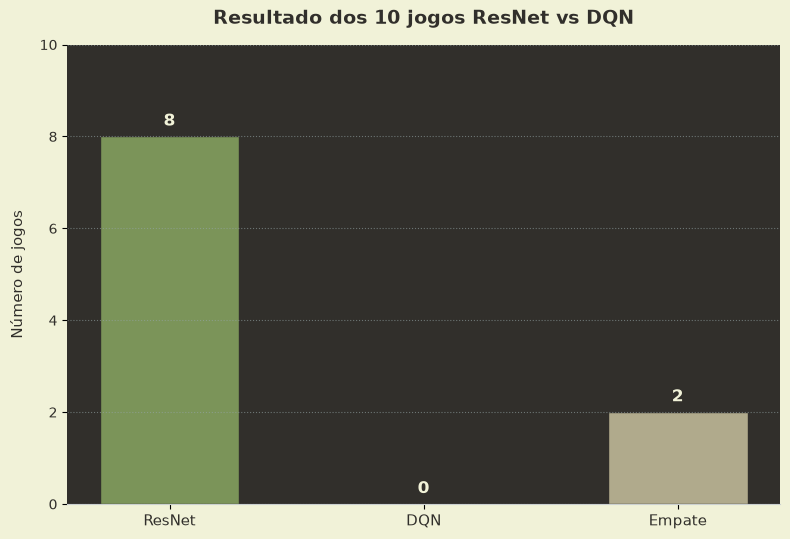

In [20]:
COR_RESNET = '#7B9459'   # mesmo verde já usado nos gráficos anteriores -- "nosso" modelo em foco
COR_DQN = '#5B7C99'      # azul, identidade fixa do DQN em todos os gráficos desta seção
COR_EMPATE = '#B0AA8C'   # neutro, para os empates

contagem = df_jogos['vencedor'].value_counts().reindex(['resnet', 'dqn', 'empate'], fill_value=0)

fig, ax = plt.subplots(figsize=(8, 5.5))
fig.patch.set_facecolor(COR_FUNDO_EXTERNO)
ax.set_facecolor(COR_FUNDO_INTERNO)

bars = ax.bar(['ResNet', 'DQN', 'Empate'], contagem.values,
              color=[COR_RESNET, COR_DQN, COR_EMPATE], edgecolor=COR_FUNDO_INTERNO, width=0.55)

for bar, val in zip(bars, contagem.values):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.15, str(val), ha='center', va='bottom',
            color=COR_FUNDO_EXTERNO, fontsize=12, fontweight='bold')

ax.set_title('Resultado dos 10 jogos ResNet vs DQN', fontsize=14, fontweight='bold', pad=15, color=COR_FUNDO_INTERNO)
ax.set_ylabel('Número de jogos', fontsize=11, labelpad=10, color=COR_FUNDO_INTERNO)
ax.set_ylim(0, 10)

ax.xaxis.set_tick_params(labelsize=11, labelcolor=COR_FUNDO_INTERNO)
ax.yaxis.set_tick_params(labelsize=10, labelcolor=COR_FUNDO_INTERNO)
ax.grid(axis='x', visible=False)
ax.grid(axis='y', linestyle=':', alpha=0.6, color='#95a5a6')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#ccd1d1')

plt.tight_layout()
plt.show()

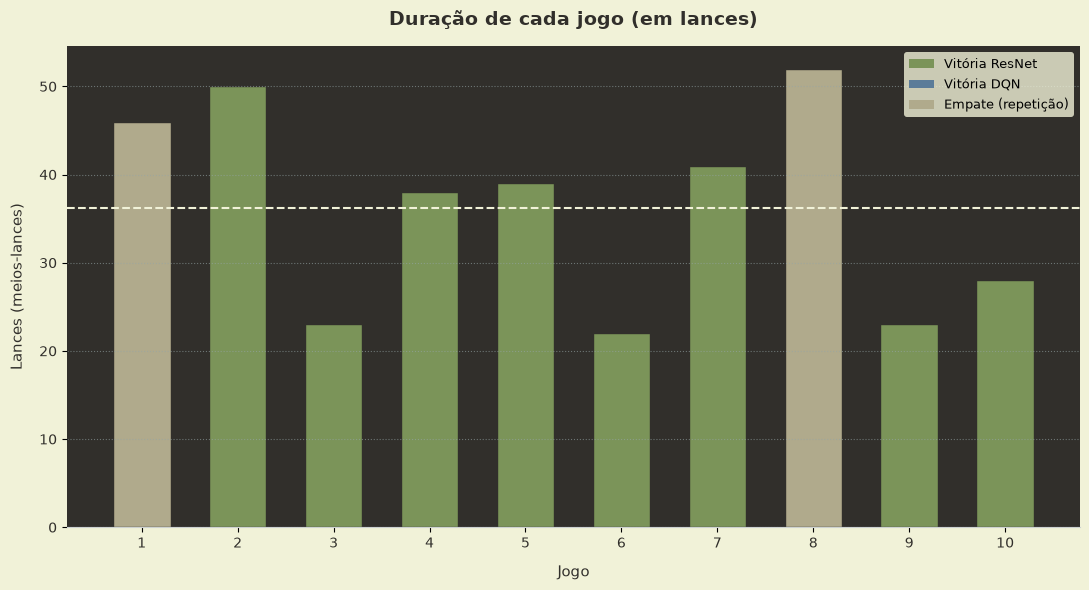

In [21]:
from matplotlib.patches import Patch

cor_por_vencedor = {'resnet': COR_RESNET, 'dqn': COR_DQN, 'empate': COR_EMPATE}
cores_barras = [cor_por_vencedor[v] for v in df_jogos['vencedor']]

fig, ax = plt.subplots(figsize=(11, 6))
fig.patch.set_facecolor(COR_FUNDO_EXTERNO)
ax.set_facecolor(COR_FUNDO_INTERNO)

ax.bar(df_jogos['jogo'].astype(str), df_jogos['lances'], color=cores_barras, edgecolor=COR_FUNDO_INTERNO, width=0.6)

media_lances = df_jogos['lances'].mean()
ax.axhline(media_lances, color=COR_FUNDO_EXTERNO, linestyle='--', linewidth=1.5,
           label=f'Média ({media_lances:.1f} lances)')

ax.set_title('Duração de cada jogo (em lances)', fontsize=14, fontweight='bold', pad=15, color=COR_FUNDO_INTERNO)
ax.set_xlabel('Jogo', fontsize=11, labelpad=10, color=COR_FUNDO_INTERNO)
ax.set_ylabel('Lances (meios-lances)', fontsize=11, labelpad=10, color=COR_FUNDO_INTERNO)

ax.xaxis.set_tick_params(labelsize=10, labelcolor=COR_FUNDO_INTERNO)
ax.yaxis.set_tick_params(labelsize=10, labelcolor=COR_FUNDO_INTERNO)
ax.grid(axis='x', visible=False)
ax.grid(axis='y', linestyle=':', alpha=0.6, color='#95a5a6')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#ccd1d1')

legend_elements = [
    Patch(facecolor=COR_RESNET, label='Vitória ResNet'),
    Patch(facecolor=COR_DQN, label='Vitória DQN'),
    Patch(facecolor=COR_EMPATE, label='Empate (repetição)'),
]
ax.legend(handles=legend_elements, frameon=True, facecolor=COR_FUNDO_EXTERNO, edgecolor='none', fontsize=9, loc='upper right')

plt.tight_layout()
plt.show()

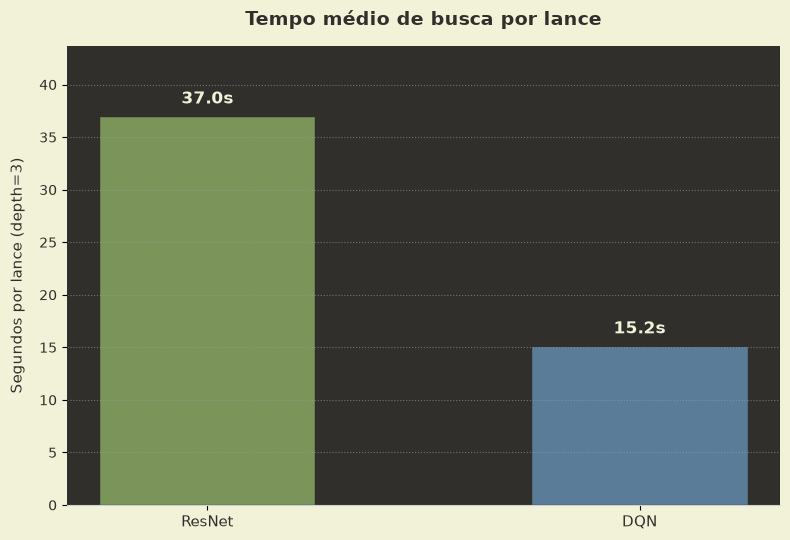

In [22]:
medias_tempo = {'ResNet': np.mean(resnet_times), 'DQN': np.mean(dqn_times)}

fig, ax = plt.subplots(figsize=(8, 5.5))
fig.patch.set_facecolor(COR_FUNDO_EXTERNO)
ax.set_facecolor(COR_FUNDO_INTERNO)

bars = ax.bar(medias_tempo.keys(), medias_tempo.values(), color=[COR_RESNET, COR_DQN],
              edgecolor=COR_FUNDO_INTERNO, width=0.5)

ax.set_ylim(0, max(medias_tempo.values()) * 1.18)

for bar, val in zip(bars, medias_tempo.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.8, f'{val:.1f}s', ha='center', va='bottom',
            color=COR_FUNDO_EXTERNO, fontsize=12, fontweight='bold')

ax.set_title('Tempo médio de busca por lance', fontsize=14, fontweight='bold', pad=15, color=COR_FUNDO_INTERNO)
ax.set_ylabel('Segundos por lance (depth=3)', fontsize=11, labelpad=10, color=COR_FUNDO_INTERNO)

ax.xaxis.set_tick_params(labelsize=11, labelcolor=COR_FUNDO_INTERNO)
ax.yaxis.set_tick_params(labelsize=10, labelcolor=COR_FUNDO_INTERNO)
ax.grid(axis='x', visible=False)
ax.grid(axis='y', linestyle=':', alpha=0.6, color='#95a5a6')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_color('#ccd1d1')

plt.tight_layout()
plt.show()

#### 3.1 Discussão

**A ResNet dominou o confronto: 8 vitórias, 2 empates e nenhuma derrota em 10 jogos, e o domínio independe da cor.** Jogando de brancas ela venceu 4 das 5 partidas (1 empate); jogando de pretas, o resultado foi idêntico (4 vitórias, 1 empate). Todas as 8 vitórias terminaram em xeque-mate: o DQN nunca conseguiu forçar uma derrota da ResNet, nem por mate nem por tempo/limite de lances.

Os 2 empates têm uma causa comum e reveladora: **repetição quíntupla**, não falta de vantagem. Nos dois casos a ResNet já estava em posição de vantagem decisiva (como já tínhamos visto no teste local anterior a este experimento) mas entrou numa sequência de xeques que se repete indefinidamente. Isso não é uma falha do modelo de avaliação, é uma limitação da busca: `MinimaxSearch` (profundidade fixa 3, sem histórico de posições) não tem como saber que já visitou aquela posição antes, então não penaliza ficar girando em círculos quando já "gosta" da avaliação atual. 
**Assimetria de tempo:** a ResNet gastou em média `~37s` por lance contra `~15s` do DQN (mediana 30.7s vs 12.3s), quase 2.5x mais lenta, apesar de ambas terem exatamente o mesmo backbone (mesmo número de blocos residuais, mesma profundidade de busca). A explicação mais provável não é o custo do forward pass da rede (idêntico nas duas arquiteturas), mas sim o formato das posições exploradas: como o DQN estava sistematicamente em desvantagem/sob ataque nas linhas jogadas, muitas de suas posições tinham poucos lances legais (rei fugindo, poucas respostas a um xeque), o que **reduz naturalmente o fator de ramificação** e portanto o tamanho da árvore de busca do próprio DQN: a busca minimax visita menos nós quando há menos lances para considerar.

**Conclusão.** Dentro deste experimento, o sinal de avaliação aprendido por supervisão direta (regressão contra centipawns do Stockfish, ResNet) produziu um jogador nitidamente mais forte do que o sinal aprendido por self-play com TD-learning (DQN, 15.000 partidas). Isso é plausível: a ResNet aprendeu a imitar uma engine já muito forte a partir de milhões de posições rotuladas, enquanto o DQN aprendeu apenas jogando contra si mesmo, sem nenhum sinal externo de "verdade" além do resultado final da partida e da diferença de material, um regime de treinamento tipicamente mais lento e mais suscetível a ficar preso em estratégias subótimas que nunca foram desafiadas por um oponente melhor.